# Regularization: Buying Simplicity with a Penalty

**DCS 404 · Data Science and Machine Learning**

---

Two modules ago, we watched a degree-14 polynomial thread itself through every noisy data point and then fail
spectacularly on data it hadn't seen. Our only remedy at the time was blunt: *use a smaller model*. Pick
degree 4 instead of 14. Turn the complexity dial down and hope you stopped at the right notch.

Today we learn a far more elegant remedy — one that lets you *keep* the big flexible model and teach it
restraint instead. The idea is almost mischievous in its simplicity: we change the cost function. Instead of
rewarding the model purely for fitting the training data, we charge it *rent* on its coefficients. Want a huge
wild coefficient? Fine — but it has to buy enough extra accuracy to cover its own cost. This is
**regularization**, and it is everywhere: it's in essentially every serious linear model in production, it's
the "weight decay" inside modern neural network training, and one version of it will even do automatic feature
selection for us — deciding, on its own, which columns of the dataset matter.

Everything we've built so far converges here. The overfitting diagnosis from the Regression module tells us
*what* goes wrong; the cost-function machinery from the Gradient Descent module tells us *where* to intervene;
and feature scaling — of all things — turns out to be a precondition for doing it fairly. Let's collect the
payoff.

## How to work through this

The usual rhythm: run every code cell (`Shift + Enter`), study the output, *then* read the commentary. Cells
build on each other, so if something errors, run from the top.

This module deliberately reuses old friends. The noisy sine-wave dataset is regenerated with *exactly the same
recipe* as in the Regression module, so the overfit you'll see in Section 1 is the very one we diagnosed
there. The student dataset from the ML Workflow module returns in Section 7 for a real-data finale. Nothing
new to download; everything runs offline from the `data/` folder.

One naming trap to flag before we start: mathematics books write the regularization strength as $\lambda$
(lambda), but scikit-learn calls the same knob `alpha` — the *same letter* we used for the learning rate in
Gradient Descent, for a completely unrelated concept. In this notebook: $\lambda$ in the maths, `alpha` in the
code, and they mean the same thing. The learning rate makes no appearance today.

## Learning objectives

After completing this module you will be able to:

- Explain the connection between overfitting and extreme coefficient values.
- Write down the regularized cost function $J = \text{SSE} + \lambda \cdot \text{penalty}$ and explain the
  role of $\lambda$ as a complexity dial.
- Fit and interpret **Ridge regression** (L2 penalty) and describe how it shrinks coefficients.
- Fit and interpret **Lasso regression** (L1 penalty) and explain why it produces exactly-zero coefficients,
  making it a feature selector.
- Explain geometrically why L1 zeroes coefficients while L2 only shrinks them.
- Explain why features must be standardised before regularizing.
- Choose the regularization strength with a validation curve, and describe how cross-validated estimators
  (`RidgeCV`, `LassoCV`) automate the choice.
- Apply lasso to a real dataset and read off which features it selected.

## Setup

Run this once. Libraries, the usual plotting style, and the student dataset (which we'll need at the end).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# A consistent look for every plot in this notebook
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("deep")
RANDOM_STATE = 0

# Load the student dataset (used in Section 7). Semicolon-separated, as always.
for candidate in [Path("data/student-mat.csv"),
                  Path("notebooks/data/student-mat.csv"),
                  Path("resources/dataset/student-mat.csv")]:
    if candidate.exists():
        students = pd.read_csv(candidate, sep=";")
        print(f"Loaded student dataset from: {candidate}")
        break
else:
    raise FileNotFoundError("Could not find student-mat.csv. Expected it in a data/ folder next to the notebook.")

print(f"Shape: {students.shape[0]} students, {students.shape[1]} columns")

Loaded student dataset from: data/student-mat.csv
Shape: 395 students, 33 columns


---
## 1. The crime scene, revisited

Let's rebuild the exact overfit from the Regression module: fifteen noisy points from a sine curve, and a
degree-14 polynomial with enough parameters to pass through every one of them.

One pipeline note before we run it. We chain three steps with scikit-learn's `make_pipeline`:
`PolynomialFeatures` manufactures $x, x^2, \dots, x^{14}$, then `StandardScaler` standardises those columns —
the very trick from the Gradient Descent module, needed here because $x^{14}$ lives on an absurdly larger
scale than $x$ — and finally `LinearRegression` fits. A pipeline just glues the steps into one object with one
`.fit()`.

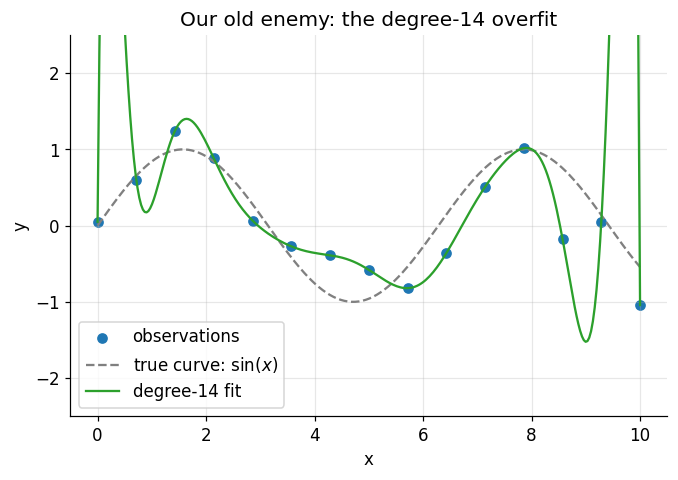

In [2]:
X_FROM, X_TO, N_POINTS = 0, 10, 15

rng = np.random.default_rng(RANDOM_STATE)
x = np.linspace(X_FROM, X_TO, N_POINTS)
y = np.sin(x) + rng.normal(scale=0.4, size=N_POINTS)   # same recipe as the Regression module
X = x.reshape(-1, 1)

grid = np.linspace(X_FROM, X_TO, 300).reshape(-1, 1)   # a fine grid for drawing prediction curves

overfit = make_pipeline(PolynomialFeatures(14, include_bias=False), StandardScaler(), LinearRegression())
overfit.fit(X, y)

plt.scatter(x, y, color="tab:blue", label="observations")
plt.plot(grid, np.sin(grid), color="grey", linestyle="--", label="true curve: $\\sin(x)$")
plt.plot(grid, overfit.predict(grid), color="tab:green", label="degree-14 fit")
plt.ylim(-2.5, 2.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Our old enemy: the degree-14 overfit")
plt.legend()
plt.show()

There it is, wiggling through every point exactly as we left it. But this time, instead of just *looking* at
the pathology, let's do the autopsy. The model is still a linear regression — fourteen features, fourteen
coefficients plus an intercept. What values did those coefficients take?

In [3]:
for degree in [1, 4, 14]:
    model = make_pipeline(PolynomialFeatures(degree, include_bias=False), StandardScaler(), LinearRegression())
    model.fit(X, y)
    coefs = model.named_steps["linearregression"].coef_
    print(f"degree {degree:>2}:  largest |coefficient| = {np.abs(coefs).max():>12,.1f}")

degree  1:  largest |coefficient| =          0.3
degree  4:  largest |coefficient| =         53.0
degree 14:  largest |coefficient| = 665,435,905.3


This is the clue that unlocks the whole module. The honest degree-4 model works with coefficients no bigger
than a few dozen. The overfit degree-14 model needs coefficients in the *hundreds of millions* — enormous
positive terms delicately cancelling enormous negative terms, a house of cards engineered to pass near every
noisy point. That's what those frantic wiggles are made of: gigantic coefficients balanced against each other.

So here's the insight: **overfitting has a signature, and the signature is extreme coefficients.** A model
telling the truth about a smooth underlying pattern doesn't need a coefficient of six hundred million. Which
suggests a wonderfully devious fix — what if we made big coefficients *expensive*?

---
## 2. The idea: charge rent on coefficients

Recall the cost function that every model so far has minimised — the sum of squared errors. Now we add a
second term:

$$J(\boldsymbol\beta) = \underbrace{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}_{\text{fit the data}}
\; + \; \lambda \cdot \underbrace{\text{penalty}(\boldsymbol\beta)}_{\text{stay simple}}$$

The penalty is some measure of how *big* the coefficients are (two specific choices coming in the next two
sections). The optimiser — whether closed-form or gradient descent — now has to serve two masters at once: fit
the training points *and* keep the coefficients small. A wild coefficient is only worth having if the accuracy
it buys outweighs the penalty it incurs. Rent, due at every fit.

The new hyperparameter $\lambda \geq 0$ sets the rent level, and its two extremes are worth internalising
before we compute anything:

- **$\lambda = 0$**: rent is free, the penalty vanishes, and we're back to ordinary least squares —
  wiggles and all.
- **$\lambda \to \infty$**: rent is ruinous; every coefficient gets crushed toward zero and the model
  flattens toward a horizontal line at $\bar{y}$ — maximal underfitting.

Somewhere between those extremes lives a sweet spot: enough penalty to kill the noise-chasing wiggles, not so
much that the real pattern is crushed too. Notice what this gives us that "pick a lower degree" never could:
degree is a *coarse* dial with a handful of integer settings, but $\lambda$ is a *continuous* dial. We can
tune model complexity as finely as we like — without changing the model's form at all.

Two housekeeping notes, then we fit. First, the intercept $\beta_0$ is traditionally *not* penalised — it just
sets the overall level of the predictions, and there's nothing "complex" about a model sitting at the right
height (scikit-learn follows this convention automatically). Second, the penalty compares coefficient sizes
against each other, and that comparison is only fair if the features share a scale — a coefficient on
$x^{14}$-units is not comparable to one on $x$-units. **Standardise before you regularize.** Feature scaling,
which last module made gradient descent *faster*, here decides whether the penalty is even *meaningful*. Our
pipelines already handle it.

---
## 3. Ridge regression: the L2 penalty

The first classic choice of penalty is the sum of *squared* coefficients:

$$J(\boldsymbol\beta) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{d}\beta_j^2$$

This is **Ridge regression**, also called **L2 regularization** (the sum of squares is the squared "L2 norm"
of the coefficient vector). Squaring means the penalty grows *quadratically*: doubling a coefficient
quadruples its rent, so truly enormous coefficients — exactly the degree-14 house of cards — get punished
ferociously.

Ridge keeps the two luxuries of ordinary least squares. There's still a closed-form solution — the normal
equation gains a $\lambda$ on its diagonal,
$\hat{\boldsymbol\beta} = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$ — and
if you'd rather walk than teleport, the gradient just gains one extra term: $2\lambda\boldsymbol\beta$. Look
closely at what that does inside the gradient descent update — at every step, each coefficient gets nudged
back toward zero by an amount proportional to its own size. Deep learning calls this exact mechanism **weight
decay**, and it's running inside virtually every neural network trained today. Same idea, fancier model.

Enough theory — let's turn the dial. Same fifteen points, same degree-14 features, four settings of
$\lambda$:

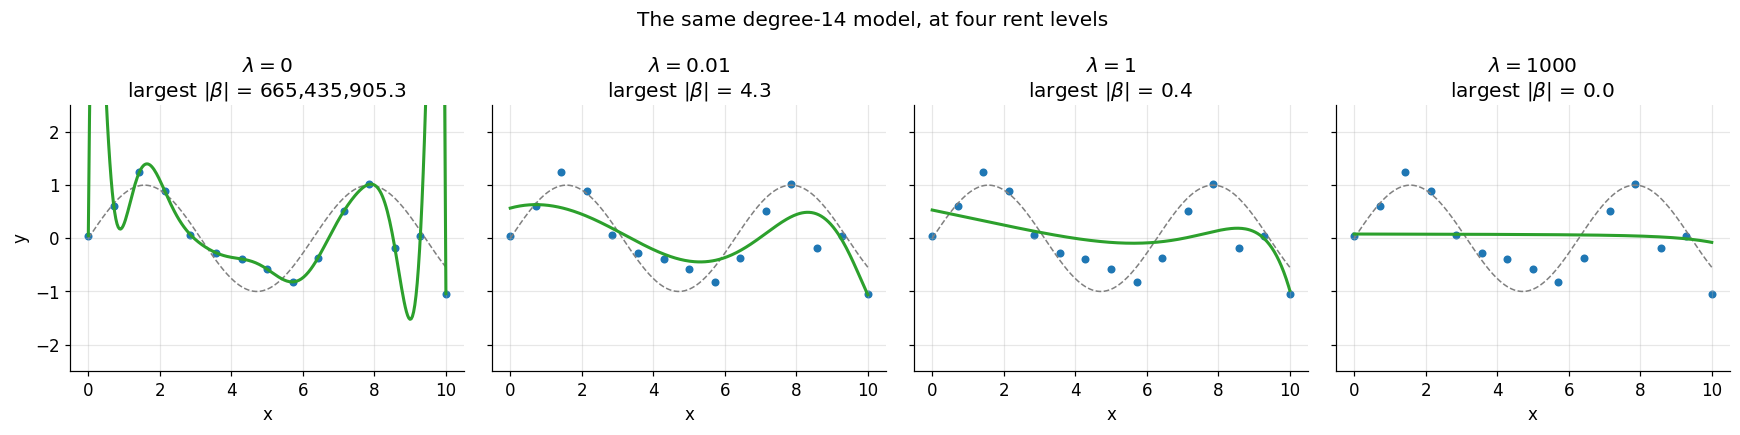

In [4]:
lambdas = [0, 0.01, 1, 1000]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, lam in zip(axes, lambdas):
    if lam == 0:
        reg = LinearRegression()          # ridge with zero penalty IS ordinary least squares
    else:
        reg = Ridge(alpha=lam)            # sklearn calls lambda "alpha"
    model = make_pipeline(PolynomialFeatures(14, include_bias=False), StandardScaler(), reg)
    model.fit(X, y)
    largest = np.abs(model.named_steps[reg.__class__.__name__.lower()].coef_).max()

    ax.scatter(x, y, color="tab:blue", s=18)
    ax.plot(grid, np.sin(grid), color="grey", linestyle="--", linewidth=1)
    ax.plot(grid, model.predict(grid), color="tab:green", linewidth=2)
    ax.set_ylim(-2.5, 2.5)
    ax.set_xlabel("x")
    ax.set_title(f"$\\lambda = {lam}$\nlargest $|\\beta|$ = {largest:,.1f}")

axes[0].set_ylabel("y")
fig.suptitle("The same degree-14 model, at four rent levels")
plt.tight_layout()
plt.show()

Read the panels left to right — it's the whole module in one figure:

- **$\lambda = 0$**: free rent, the full overfit, coefficients in the hundreds of millions.
- **$\lambda = 0.01$**: a *whisper* of penalty and the house of cards collapses — the huge cancelling
  coefficients can't pay even token rent, and the curve relaxes into a shape hugging the true sine wave. Look
  at the coefficient readout: *eight orders of magnitude* smaller.
- **$\lambda = 1$**: firmer rent, and now clearly too much of it — the wave itself is being taxed away,
  leaving only a gentle drift through the data.
- **$\lambda = 1000$**: ruinous rent. The model has been taxed into a near-horizontal line through the mean.
  We've regularized our way straight into underfitting.

Same fourteen degrees of freedom in every panel. What changed is not the model's *capacity* but its *budget* —
and that's the philosophical shift of this module: complexity isn't what a model *could* do, it's what it can
*afford* to do.

---
## 4. Lasso regression: the L1 penalty

The second classic penalty looks almost identical — swap the squares for absolute values:

$$J(\boldsymbol\beta) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{d}|\beta_j|$$

This is **Lasso regression** (**L1 regularization**). One character of algebra changed; the behaviour changes
in a way nobody would guess from the formula. Ridge *shrinks* coefficients — smoothly, proportionally, and
never quite to zero; a coefficient at 0.001 is paying almost no L2 rent, so there's no pressure to finish the
job. But under L1, the rent per unit stays the *same* all the way down — the last millimetre to zero saves as
much rent as any other millimetre. So for any feature whose contribution can't cover that flat rate, the
optimum is *exactly* zero. Not small. Zero.

A zeroed coefficient means the feature is simply *gone* from the model. Lasso doesn't just discourage
complexity — it performs **automatic feature selection**, deciding which columns of your dataset earn their
keep. Watch it work on our fourteen polynomial features:

In [5]:
ridge_model = make_pipeline(PolynomialFeatures(14, include_bias=False), StandardScaler(), Ridge(alpha=0.01))
lasso_model = make_pipeline(PolynomialFeatures(14, include_bias=False), StandardScaler(),
                            Lasso(alpha=0.001, max_iter=100_000))
ridge_model.fit(X, y)
lasso_model.fit(X, y)

coefs = pd.DataFrame({
    "ridge (λ=0.01)": ridge_model.named_steps["ridge"].coef_,
    "lasso (λ=0.001)": lasso_model.named_steps["lasso"].coef_,
}, index=[f"x^{p}" for p in range(1, 15)])

for name, col in coefs.items():
    kept = (col != 0).sum()
    print(f"{name}: {kept} of 14 coefficients non-zero")

coefs.round(3)

ridge (λ=0.01): 14 of 14 coefficients non-zero
lasso (λ=0.001): 5 of 14 coefficients non-zero


,ridge (λ=0.01),lasso (λ=0.001)
x^1,0.574,1.866
x^2,-4.332,-8.138
x^3,1.392,0.000
x^4,3.201,12.217
x^5,2.387,0.000
x^6,0.781,-0.000
x^7,-0.652,-0.000
x^8,-1.549,-8.733
x^9,-1.856,-0.000
x^10,-1.655,-0.000


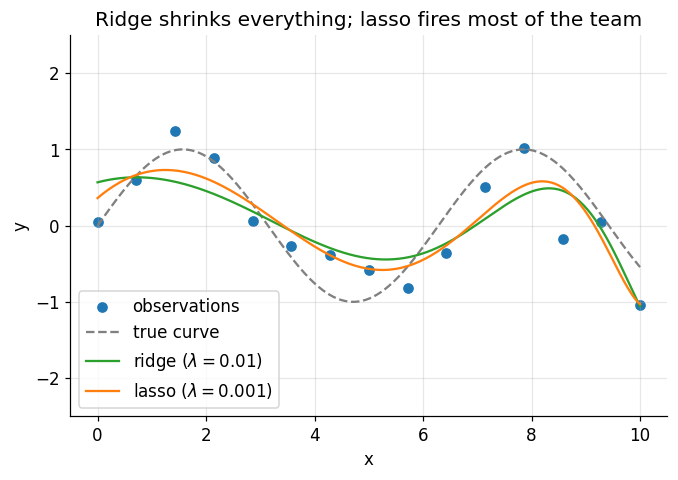

In [6]:
plt.scatter(x, y, color="tab:blue", label="observations")
plt.plot(grid, np.sin(grid), color="grey", linestyle="--", label="true curve")
plt.plot(grid, ridge_model.predict(grid), color="tab:green", label="ridge ($\\lambda=0.01$)")
plt.plot(grid, lasso_model.predict(grid), color="tab:orange", label="lasso ($\\lambda=0.001$)")
plt.ylim(-2.5, 2.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ridge shrinks everything; lasso fires most of the team")
plt.legend()
plt.show()

Study the coefficient table before the plot. Ridge kept all fourteen features on the payroll, every one
shrunk to modest size. Lasso looked at the same fourteen candidates and *fired nine of them* — exact zeros,
struck off the model — keeping only the five polynomial terms that genuinely earn their rent. Yet both
prediction curves trace a perfectly respectable sine-ish shape. Lasso is telling us something true: you don't
*need* fourteen polynomial terms to describe this data. A few suffice.

That's the practical division of labour. **Ridge** when you believe many features each contribute a little and
you want them all tamed. **Lasso** when you suspect most features are irrelevant and want the model to say so
out loud. (And if you want both behaviours at once, **Elastic Net** blends the two penalties — it's one import
away as `sklearn.linear_model.ElasticNet`.)

But *why* does the absolute value produce exact zeros while the square never does? The formula-level answer —
flat rent versus vanishing rent near zero — is correct but abstract. There's a picture that makes it click.

---
## 5. Why L1 zeroes and L2 doesn't: the picture

There's an equivalent way to think about the penalty: instead of "SSE plus rent", imagine minimising the SSE
subject to a *budget* — the coefficients must live inside a region of limited total size. For L2 the region is
a **circle** ($\beta_1^2 + \beta_2^2 \leq$ budget); for L1 it's a **diamond**
($|\beta_1| + |\beta_2| \leq$ budget), with sharp corners sitting exactly *on the axes* — and on an axis, one
coefficient is exactly zero.

The unregularized optimum (the OLS solution) usually lies outside the budget region, and the constrained
solution is the point where the SSE's elliptical contours first kiss the region's boundary:

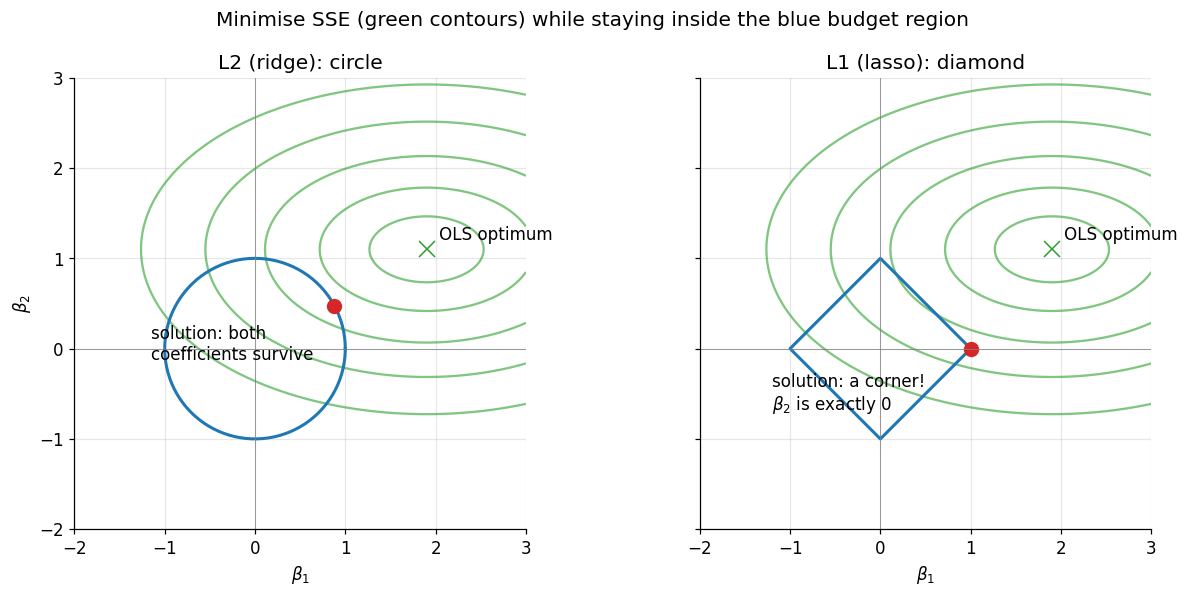

In [7]:
# Elliptical SSE contours around an (arbitrary) OLS optimum, plus each budget region
b1, b2 = np.meshgrid(np.linspace(-2, 3, 400), np.linspace(-2, 3, 400))
sse = 1.0 * (b1 - 1.9) ** 2 + 3.0 * (b2 - 1.1) ** 2         # a stretched bowl, minimum at (1.9, 1.1)

theta = np.linspace(0, 2 * np.pi, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)

for ax, shape in zip(axes, ["L2 (ridge): circle", "L1 (lasso): diamond"]):
    ax.contour(b1, b2, sse, levels=[0.4, 1.4, 3.2, 6.0, 10.0], colors="tab:green", alpha=0.6)
    ax.plot(1.9, 1.1, marker="x", color="tab:green", markersize=10)
    ax.annotate("OLS optimum", (1.9, 1.1), textcoords="offset points", xytext=(8, 6))
    if shape.startswith("L2"):
        ax.plot(np.cos(theta), np.sin(theta), color="tab:blue", linewidth=2)
        ax.plot(0.88, 0.47, marker="o", color="tab:red", markersize=9)   # roughly where contours kiss the circle
        ax.annotate("solution: both\ncoefficients survive", (0.88, 0.47),
                    textcoords="offset points", xytext=(-120, -35))
    else:
        ax.plot([1, 0, -1, 0, 1], [0, 1, 0, -1, 0], color="tab:blue", linewidth=2)
        ax.plot(1, 0, marker="o", color="tab:red", markersize=9)          # the contours hit the corner
        ax.annotate("solution: a corner!\n$\\beta_2$ is exactly 0", (1, 0),
                    textcoords="offset points", xytext=(-130, -40))
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.axvline(0, color="grey", linewidth=0.5)
    ax.set_xlabel("$\\beta_1$")
    ax.set_title(shape)
    ax.set_aspect("equal")

axes[0].set_ylabel("$\\beta_2$")
fig.suptitle("Minimise SSE (green contours) while staying inside the blue budget region")
plt.tight_layout()
plt.show()

The green ellipses are contour lines of the SSE — rings of equal training error spreading out from the OLS
optimum, like altitude lines on a map of last module's loss bowl viewed from above. The best coefficients we
can afford sit where the smallest possible ellipse touches the blue region.

Against the **circle**, that first touch can happen anywhere on the smooth boundary — and generically it lands
at some diagonal point where *both* coefficients are non-zero, just modest. Against the **diamond**, the
expanding ellipses are overwhelmingly likely to strike a *corner* first — the corners poke outward, they're
the "closest approaches" of the region — and every corner has a coefficient pinned at exactly zero. Scale this
picture up from 2 coefficients to 14 (or 14,000) and the corners multiply combinatorially: high-dimensional
diamonds are almost *all* corners and edges. That's why lasso solutions are sparse and ridge solutions never
are: not a quirk of the optimiser, but the geometry of absolute values.

---
## 6. Choosing $\lambda$: the U-curve returns

So how much rent is the *right* rent? We already own the answer, because we've solved this exact problem shape
once before. In the Regression module, "how much complexity?" meant *which polynomial degree*, and the answer
was: measure held-out error and find the bottom of the U. Now the complexity dial is $\lambda$ — pointing the
opposite way, since *more* $\lambda$ means *less* complexity — but the method is identical. Split the data,
sweep the dial, watch both errors:

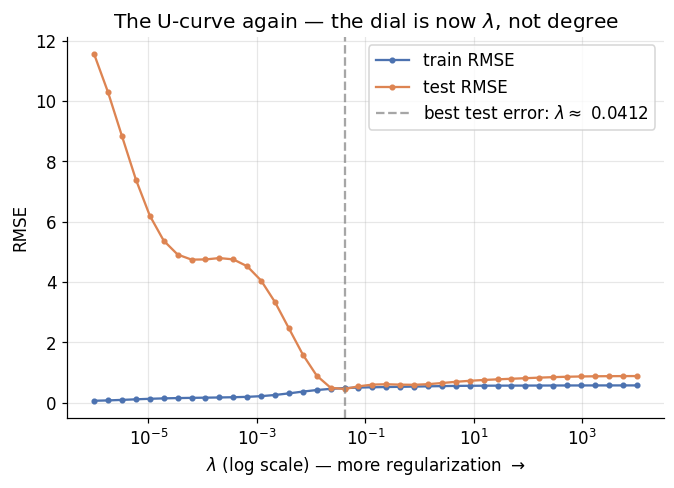

In [8]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

lambda_grid = np.logspace(-6, 4, 40)
records = []
for lam in lambda_grid:
    model = make_pipeline(PolynomialFeatures(14, include_bias=False), StandardScaler(), Ridge(alpha=lam))
    model.fit(Xr_train, yr_train)
    records.append({
        "lambda": lam,
        "train RMSE": np.sqrt(mean_squared_error(yr_train, model.predict(Xr_train))),
        "test RMSE": np.sqrt(mean_squared_error(yr_test, model.predict(Xr_test))),
    })

curve = pd.DataFrame(records).set_index("lambda")
best_lambda = curve["test RMSE"].idxmin()

plt.plot(curve.index, curve["train RMSE"], marker=".", label="train RMSE")
plt.plot(curve.index, curve["test RMSE"], marker=".", label="test RMSE")
plt.axvline(best_lambda, color="grey", linestyle="--", alpha=0.7,
            label=f"best test error: $\\lambda \\approx$ {best_lambda:.3g}")
plt.xscale("log")
plt.xlabel("$\\lambda$ (log scale) — more regularization $\\rightarrow$")
plt.ylabel("RMSE")
plt.title("The U-curve again — the dial is now $\\lambda$, not degree")
plt.legend()
plt.show()

Same story, new dial. At the far left ($\lambda \approx 0$) the penalty is negligible: training error is
superb and test error is dreadful — overfitting. At the far right the model is taxed toward a flat line and
both errors drift upward — underfitting (gently, here: for a wave that only spans $\pm 1$, even a flat line
isn't catastrophically wrong, but the trend is unmistakable). Test error bottoms out in between, and notice
how *wide* and forgiving that valley is on the log scale: getting $\lambda$ within an order of magnitude of optimal captures most of the
benefit. This is why practitioners sweep $\lambda$ on a log grid (0.001, 0.01, 0.1, ...), never a linear one.

One honest caveat: with only fifteen points, our single train/test split makes this curve a bit lucky-or-
unlucky — a different split would move the bottom of the U around. The industrial-strength fix is
**cross-validation**: rotate which slice of the data is held out, average the errors, and trust the average.
It's important enough to get its own treatment in a later module; for now, know that scikit-learn packages the
whole sweep-and-cross-validate routine into drop-in estimators —
[`RidgeCV`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html) and
[`LassoCV`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html) — which tune
$\lambda$ for you as part of `.fit()`. We'll use one right now.

---
## 7. The finale: lasso reads the student data

Synthetic sine waves are for building intuition; the real test of a feature selector is a dataset with
genuinely competing features. Enter, one last time, the student performance data. We'll take every numeric
feature — fifteen of them, from study time to alcohol consumption — standardise, and ask `LassoCV` to predict
the final grade `G3` while choosing $\lambda$ by cross-validation. The question we're really asking: *out of
everything we know about a student, what does the model decide it actually needs?*

In [9]:
numeric = students.select_dtypes(include="number")
X_stu = numeric.drop(columns="G3")
y_stu = numeric["G3"]
print(f"{X_stu.shape[1]} numeric features: {list(X_stu.columns)}")

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_stu, y_stu, test_size=0.2, random_state=RANDOM_STATE)

lasso_cv = make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=RANDOM_STATE))
lasso_cv.fit(Xs_train, ys_train)

chosen = lasso_cv.named_steps["lassocv"]
print(f"\nlambda chosen by cross-validation: {chosen.alpha_:.4f}")
print(f"features kept: {(chosen.coef_ != 0).sum()} of {X_stu.shape[1]}")

15 numeric features: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

lambda chosen by cross-validation: 0.0697
features kept: 9 of 15


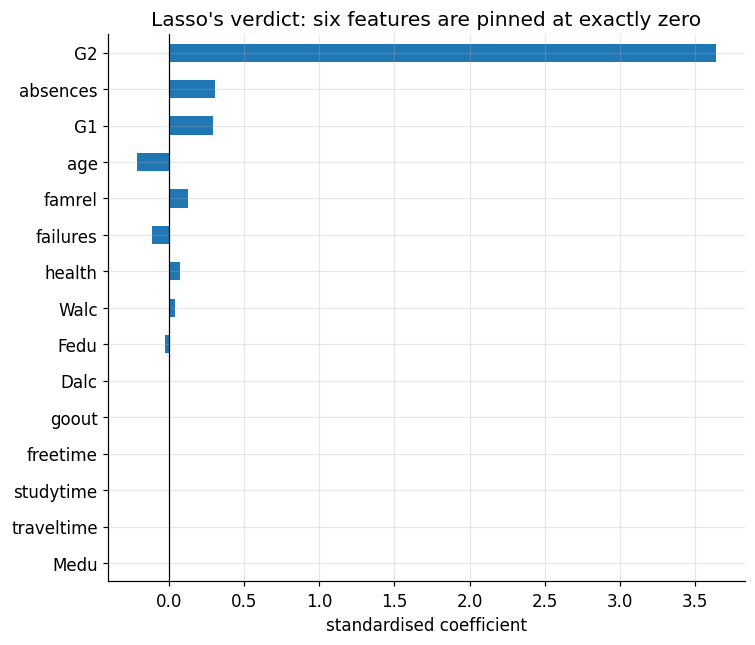

Fedu       -0.027
Walc        0.035
health      0.070
failures   -0.114
famrel      0.128
age        -0.214
G1          0.290
absences    0.302
G2          3.640
dtype: float64

In [10]:
coef_table = (pd.Series(chosen.coef_, index=X_stu.columns)
                .sort_values(key=np.abs, ascending=True))

coef_table.plot.barh(color="tab:blue", figsize=(7, 6))
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("standardised coefficient")
plt.title("Lasso's verdict: six features are pinned at exactly zero")
plt.tight_layout()
plt.show()

coef_table[coef_table != 0].round(3)

Read the bar chart from the bottom up — it's a ranked verdict on the whole dataset. Six features have
vanished entirely: `Medu`, `traveltime`, `studytime`, `freetime`, `goout`, and `Dalc` sit at *exact* zero —
bars of no width, struck from the model. What survives is dominated overwhelmingly by `G2` — the
second-period grade, with a coefficient more than ten times any other — which we already knew from the ML
Workflow module was doing most of the predictive work. `absences`, `G1`, and a few others cling on with small
coefficients.

Two cautions before we get carried away. First, "fired" means *redundant for prediction given the others*, not
*irrelevant in life*: `G1` carries real information, but with `G2` already in the room it adds almost nothing
— our old multicollinearity lesson wearing a new coat. Second, a lasso coefficient is still a correlation-
world object, not a causal one — the model isn't saying failing fewer classes *causes* higher grades, only
that it helps predict them.

Does the pruning cost us accuracy? Let's compare against plain, keep-everything linear regression:

In [11]:
ols_pipe = make_pipeline(StandardScaler(), LinearRegression())
ols_pipe.fit(Xs_train, ys_train)

for name, model in [("OLS, all 15 features", ols_pipe), ("LassoCV", lasso_cv)]:
    rmse = np.sqrt(mean_squared_error(ys_test, model.predict(Xs_test)))
    print(f"{name:<22} test RMSE = {rmse:.3f}")

OLS, all 15 features   test RMSE = 2.308
LassoCV                test RMSE = 2.309


Essentially the same test error, from a model that threw most of its inputs away. That's the quiet
superpower of regularization on real data: it doesn't just prevent overfitting — it buys you *simpler,
cheaper, more explainable* models at no accuracy cost. A school deploying the lasso model needs nine fields
instead of thirty-two, and in truth mostly one; a stakeholder asking "what drives the prediction?" gets an
answer that fits in a sentence.

And when does regularization go from "nice to have" to "load-bearing"? Whenever the feature count is large
relative to the data — hundreds of features, thousands of engineered polynomial terms, or (the extreme case)
more features than samples, where OLS doesn't even have a unique solution but ridge and lasso happily do.
In modern practice you'll meet very few unregularized linear models in the wild.

---
## 8. Your turn

Add cells below each exercise. Exercises 2 and 5 are the ones that consolidate the big ideas.

**Exercise 1 — Ridge reads the students.**
Repeat Section 7 with `RidgeCV` (import it from `sklearn.linear_model`) in place of `LassoCV`. Compare the
coefficient bar charts side by side. Does ridge agree with lasso about which features matter *most*? What does
it do with the features lasso fired?

**Exercise 2 — Break the tie to scaling.**
In Section 7, remove the `StandardScaler` step from the lasso pipeline and refit. Which features get kept
now? Look at the raw value ranges of those features (`X_stu.describe()`) and explain what went wrong — why is
the penalty unfair without scaling?

**Exercise 3 — The ruinous-rent limit.**
We claimed that as $\lambda \to \infty$ the model flattens to a horizontal line at $\bar{y}$. Verify it: fit
Ridge with `alpha=1e9` on the sine data, predict over the grid, and compare against `y.mean()`. Why the mean,
and not zero? (Hint: which coefficient never pays rent?)

**Exercise 4 — Noise moves the dial.**
Regenerate the sine data with noise `scale=0.8` (double) and rerun the validation curve of Section 6. Which
way does the best $\lambda$ move? Explain in one sentence using the rent metaphor.

**Exercise 5 — The full sweep.**
Combine everything: on the sine data, plot test RMSE against $\lambda$ for *both* ridge and lasso on the same
axes. Which achieves the lower minimum here? Then repeat the plot's *idea* on the student data (ridge vs lasso
test RMSE at their CV-chosen $\lambda$'s). Is there a meaningful difference — and if not, what would make you
still prefer one over the other in a report to the school?

---
## 9. If you remember nothing else

1. Overfitting has a signature: extreme coefficients, delicately cancelling, engineered to chase noise. Our
   degree-14 model needed coefficients in the hundreds of millions to wiggle through fifteen points.

2. Regularization changes the cost function: $J = \text{SSE} + \lambda \cdot \text{penalty}$. Fit the data,
   *and* pay rent on your coefficients. $\lambda$ is a continuous complexity dial: 0 recovers OLS, $\infty$
   flattens the model into underfitting; tune it on held-out error, on a log grid.

3. **Ridge (L2)** penalises $\sum \beta_j^2$: shrinks all coefficients smoothly, never exactly to zero. Its
   gradient-descent form — nudge every weight toward zero at each step — is deep learning's "weight decay".

4. **Lasso (L1)** penalises $\sum |\beta_j|$: drives unhelpful coefficients *exactly* to zero, performing
   automatic feature selection. Geometrically: elliptical error contours hit the corners of the L1 diamond,
   and corners live on the axes.

5. Standardise before you regularize — the penalty compares coefficient sizes, and that's only fair on a
   shared scale. The intercept is never penalised.

6. Choosing $\lambda$ is the degree-choosing problem in new clothes: the same U-curve, found the same way,
   ideally with cross-validation (`RidgeCV`, `LassoCV` automate it).

7. On real data, lasso matched keep-everything OLS on the student test set while zeroing six features and
   leaning almost entirely on one — regularization buys simplicity and explainability, often at zero accuracy
   cost.

8. Rule of thumb: many features, engineered features, or few samples per feature → regularize. In practice:
   almost always regularize.

---
## 10. Further reading and glossary

### Further reading

- *An Introduction to Statistical Learning*, [Chapter 6](https://www.statlearning.com/) — shrinkage methods:
  ridge, lasso, and the budget-region picture in full statistical dress.
- scikit-learn's guide to [linear models](https://scikit-learn.org/stable/modules/linear_model.html) — Ridge,
  Lasso, ElasticNet and their CV variants, with practical notes.
- The scikit-learn example on [lasso and elastic net paths](https://scikit-learn.org/stable/auto_examples/linear_model/plot_lasso_coordinate_descent_path.html)
  — watch every coefficient's journey to zero as $\lambda$ grows.
- Robert Tibshirani's original 1996 paper, [Regression Shrinkage and Selection via the Lasso](https://webdoc.sub.gwdg.de/ebook/serien/e/CIS/12290.pdf)
  — surprisingly readable, and a nice example of what a landmark methods paper looks like.

### Glossary

| Term | Meaning |
|---|---|
| Regularization | Adding a coefficient-size penalty to the cost function to discourage overfitting. |
| Penalty term | The $\lambda \cdot \text{penalty}(\boldsymbol\beta)$ addition to the SSE — the "rent". |
| $\lambda$ / `alpha` | Regularization strength; sklearn's name for $\lambda$ is `alpha` (unrelated to the learning rate). |
| Ridge regression | Linear regression with an L2 penalty $\sum \beta_j^2$. |
| Lasso regression | Linear regression with an L1 penalty $\sum |\beta_j|$. |
| L1 / L2 norm | Sum of absolute values / square root of sum of squares of a vector's entries. |
| Shrinkage | Pulling coefficient estimates toward zero — what all regularizers do. |
| Sparsity | Many coefficients exactly zero; the hallmark of L1 solutions. |
| Feature selection | Choosing which features enter the model; lasso does it automatically. |
| Weight decay | Deep learning's name for L2 regularization inside gradient-based training. |
| Elastic Net | A blend of L1 and L2 penalties, controlled by a mixing ratio. |
| Validation curve | Train/test error plotted against a hyperparameter — how we find the U's bottom. |
| Cross-validation | Averaging held-out error over rotating splits for a more reliable estimate. |
| `RidgeCV` / `LassoCV` | Estimators that tune $\lambda$ by cross-validation during `.fit()`. |
| Intercept exemption | The convention that $\beta_0$ is never penalised. |